<a href="https://colab.research.google.com/github/mena-shehata45/ETT_time_series_modeling/blob/main/ETT_time_series_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
from huggingface_hub import hf_hub_download

repo_id = "Duyu/Time-Series-Forecasting-Benchmark-Datasets"

# change filename to: "ETTh2.csv", "ETTm1.csv", "ETTm2.csv" if you want
filename = "ETTh1.csv"

local_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    repo_type="dataset"
)

print("Downloaded to:", local_path)

df = pd.read_csv(local_path)
df.columns = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
df.columns

ETTh1.csv: 0.00B [00:00, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--Duyu--Time-Series-Forecasting-Benchmark-Datasets/snapshots/33414556cf7d6054bf1c6c98e9e53cd6e9a377b0/ETTh1.csv


Index(['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='object')

In [8]:
df.shape

(17419, 7)

In [9]:
df.describe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17419.000000,17419.000000,17419.000000,17419.000000,17419.000000,17419.000000,17419.000000
mean,7.375230,2.242256,4.300394,0.881592,3.065997,0.856904,13.323684
std,7.067937,2.042400,6.827144,1.809343,1.164508,0.599558,8.566200
min,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,5.827000,0.737000,3.305000,-0.284000,2.315000,0.670000,6.964000
50%,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000


In [10]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
1,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
3,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
4,5.626,2.143,1.528,0.533,4.051,1.371,21.174000


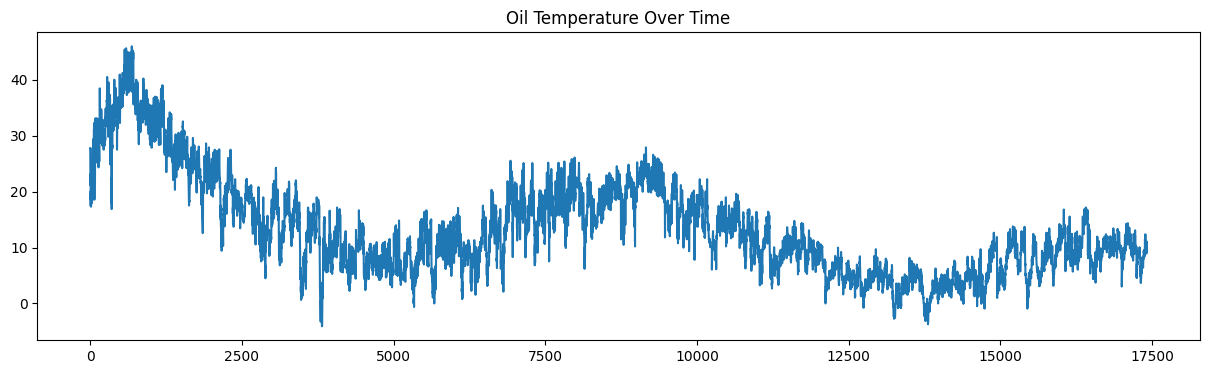

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(df['OT'])
plt.title("Oil Temperature Over Time")
plt.show()

also we need to do the split manually because we are using time series data so the sequence actually matters so we cant use the train split function with schuffle on because everything will go wrong

In [12]:
train_split = 0.7
val_split = 0.85
len(df)

train_data = df[:int(train_split * len(df))]
val_data   = df[int(train_split * len(df)): int(val_split * len(df))]
test_data  = df[int(val_split * len(df)):]

train_data.shape, val_data.shape, test_data.shape

((12193, 7), (2613, 7), (2613, 7))

so here we need to do the scaling after the splitting because otherwise we will have data leakage as the scaler now has info from the future

we knows the mean and variance the distribution of the test dataset and thats noooo goood

In [13]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)


In [14]:
import pandas as pd

train_scaled = pd.DataFrame(train_scaled, columns=train_data.columns)
val_scaled   = pd.DataFrame(val_scaled, columns=val_data.columns)
test_scaled  = pd.DataFrame(test_scaled, columns=test_data.columns)

In [15]:
train_scaled.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,-0.275856,0.056323,-0.496613,-0.138827,1.031536,0.891521,1.376821
1,-0.360250,-0.102213,-0.531207,-0.175660,0.724439,0.660552,1.376821
2,-0.370799,-0.007092,-0.531207,-0.156984,0.749680,0.752637,1.048232
3,-0.328602,-0.007092,-0.496613,-0.120152,0.801003,0.752637,0.677357
4,-0.286406,0.088030,-0.490766,-0.083319,0.954972,0.891521,0.584638


In [16]:
X_cols = df.columns.tolist()
y_col = "OT"
y_idx = X_cols.index(y_col)

In [17]:
input_len = 96
horizon = 24        # how many nums should be predicted 24 hours in this case

Lets first start with a linear regression model as our baseline to compare in modeling this time series data


---------------

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader

class MultivariateWindowDataset(Dataset):
    def __init__(self, data_df, y_idx, input_len=96, horizon=24):
        self.data = torch.tensor(data_df.values, dtype=torch.float32)
        self.y_idx = y_idx
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.input_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_len]  # (96, num_features)
        y = self.data[idx + self.input_len : idx + self.input_len + self.horizon, self.y_idx]  # (24,)
        return x, y

In [19]:
input_len = 96
horizon   = 24
batch_size = 64

train_ds = MultivariateWindowDataset(train_scaled, y_idx, input_len, horizon)
val_ds   = MultivariateWindowDataset(val_scaled,   y_idx, input_len, horizon)
test_ds  = MultivariateWindowDataset(test_scaled,  y_idx, input_len, horizon)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [20]:
import numpy as np

def loader_to_numpy(loader):
    X_list = []
    y_list = []

    for xb, yb in loader:
        # flatten time dimension because the linear regression take all inputs as one dimension
        xb = xb.view(xb.size(0), -1)   # (batch, 96*7)
        X_list.append(xb.numpy())
        y_list.append(yb.numpy())

    X = np.vstack(X_list)
    y = np.vstack(y_list)

    return X, y



In [21]:
xb, yb = next(iter(train_loader))
print("X batch:", xb.shape)  # (64, 96, 7)
print("y batch:", yb.shape)  # (64, 24)

X batch: torch.Size([64, 96, 7])
y batch: torch.Size([64, 24])


In [22]:
x_train, y_train = loader_to_numpy(train_loader)
x_val, y_val = loader_to_numpy(val_loader)
x_test, y_test = loader_to_numpy(test_loader)

In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [24]:
y_pred_train = lr.predict(x_train)
y_pred_val   = lr.predict(x_val)
y_pred_test  = lr.predict(x_test)

y_pred_train.shape

(12032, 24)

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, mae

train_mse, train_mae = evaluate(y_train, y_pred_train)
val_mse, val_mae     = evaluate(y_val, y_pred_val)
test_mse, test_mae   = evaluate(y_test, y_pred_test)

print("Train MAE:", train_mae)
print("Val MAE:", val_mae)
print("Test MAE:", test_mae)

Train MAE: 0.20245933532714844
Val MAE: 0.15397745370864868
Test MAE: 0.16500407457351685


In [26]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

alphas = [0.1, 1, 10, 100]

best_alpha = None
best_val_mae = float("inf")

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(x_train, y_train)

    val_pred = model.predict(x_val)
    val_mae = mean_absolute_error(y_val, val_pred)

    print(f"alpha={alpha}, val MAE={val_mae}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_alpha = alpha

print("Best alpha:", best_alpha)

alpha=0.1, val MAE=0.15397171676158905
alpha=1, val MAE=0.1539270132780075
alpha=10, val MAE=0.15365105867385864
alpha=100, val MAE=0.1533130407333374
Best alpha: 100


In [27]:
model_ridge = Ridge(alpha=best_alpha)
model_ridge.fit(x_train, y_train)

test_pred = model_ridge.predict(x_test)
print("Test MAE:", mean_absolute_error(y_test, test_pred))

Test MAE: 0.16446013748645782


Let's try it then with the RNN and see how is it compared to the Linear Regression



In [28]:
import torch
import torch.nn as nn

class SimpleRNNForecaster(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=1, horizon=24, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (B, T, F)
        out, h = self.rnn(x)          # out: (B, T, H)
        last = out[:, -1, :]          # (B, H)
        yhat = self.fc(last)          # (B, 24)
        return yhat

In [42]:
import torch.optim as optim

def run_epoch(model, loader, optimizer=None, device="cpu"):
    train = optimizer is not None
    model.train() if train else model.eval()

    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    total_mse, total_mae, n = 0.0, 0.0, 0

    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb = xb.to(device)                 # (B, 96, 7)
            yb = yb.to(device)                 # (B, 24)

            pred = model(xb)                   # (B, 24)

            loss_mse = mse_fn(pred, yb)
            loss_mae = mae_fn(pred, yb)

            if train:
                optimizer.zero_grad()
                loss_mse.backward()            # optimize MSE (standard)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            bs = xb.size(0)
            total_mse += loss_mse.item() * bs
            total_mae += loss_mae.item() * bs

            n += bs

    return total_mse / n, total_mae / n

In [38]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

num_features = 7
horizon = 24

model = SimpleRNNForecaster(num_features=num_features, hidden_size=64, num_layers=1, horizon=horizon).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_val = float("inf")
best_state = None


epochs = 20
for epoch in range(1, epochs + 1):
    train_mse, train_mae = run_epoch(model, train_loader, optimizer, device)
    val_mse, val_mae     = run_epoch(model, val_loader, None, device)

    print(f"Epoch {epoch:02d} | Train MAE {train_mae:.4f} | Val MAE {val_mae:.4f}")

    if val_mae < best_val:
        best_val = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# load best model
model.load_state_dict(best_state)

Epoch 01 | Train MAE 0.3231 | Val MAE 0.2603
Epoch 02 | Train MAE 0.2420 | Val MAE 0.2139
Epoch 03 | Train MAE 0.2337 | Val MAE 0.2245
Epoch 04 | Train MAE 0.2270 | Val MAE 0.2683
Epoch 05 | Train MAE 0.2213 | Val MAE 0.2366
Epoch 06 | Train MAE 0.2182 | Val MAE 0.2023
Epoch 07 | Train MAE 0.2186 | Val MAE 0.3520
Epoch 08 | Train MAE 0.2179 | Val MAE 0.1981
Epoch 09 | Train MAE 0.2156 | Val MAE 0.2160
Epoch 10 | Train MAE 0.2160 | Val MAE 0.2567
Epoch 11 | Train MAE 0.2145 | Val MAE 0.2924
Epoch 12 | Train MAE 0.2144 | Val MAE 0.2857
Epoch 13 | Train MAE 0.2140 | Val MAE 0.2625
Epoch 14 | Train MAE 0.2119 | Val MAE 0.1870
Epoch 15 | Train MAE 0.2132 | Val MAE 0.2796
Epoch 16 | Train MAE 0.2112 | Val MAE 0.2778
Epoch 17 | Train MAE 0.2101 | Val MAE 0.1963
Epoch 18 | Train MAE 0.2093 | Val MAE 0.2238
Epoch 19 | Train MAE 0.2089 | Val MAE 0.2586
Epoch 20 | Train MAE 0.2076 | Val MAE 0.2689


<All keys matched successfully>

In [39]:
test_mse, test_mae = run_epoch(model, test_loader, None, device)
print("RNN Test MAE:", test_mae)

RNN Test MAE: 0.15323218193021695


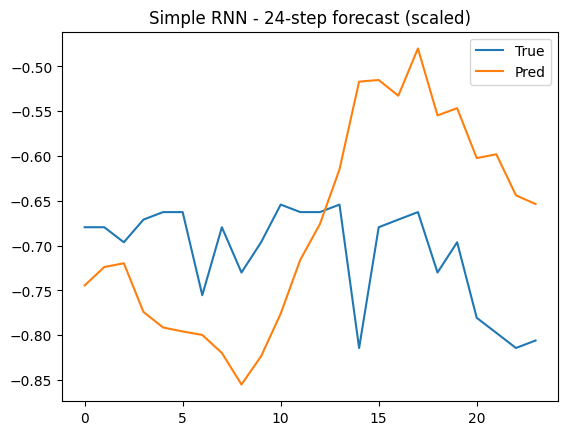

In [40]:
import matplotlib.pyplot as plt

model.eval()
xb, yb = next(iter(test_loader))
xb = xb.to(device)
with torch.no_grad():
    pred = model(xb).cpu().numpy()

true = yb.numpy()
i = 0

plt.plot(true[i], label="True")
plt.plot(pred[i], label="Pred")
plt.legend()
plt.title("Simple RNN - 24-step forecast (scaled)")
plt.show()

Now let's try with the LSTM



In [47]:
import torch.nn as nn

class SimpleLSTMForecaster(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=1, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)     # (B, T, H)
        last = out[:, -1, :]      # (B, H)
        return self.fc(last)      # (B, 24)

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_lstm(model, train_loader, val_loader, epochs=50, lr=1e-3, patience=5, device="cpu"):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # ---- train
        model.train()
        train_mae_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)

            loss = mse_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_mae_sum += mae_fn(pred, yb).item() * xb.size(0)
            n += xb.size(0)
        train_mae = train_mae_sum / n

        # ---- val
        model.eval()
        val_mae_sum, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_mae_sum += mae_fn(pred, yb).item() * xb.size(0)
                n += xb.size(0)
        val_mae = val_mae_sum / n

        print(f"Epoch {epoch:02d} | Train MAE {train_mae:.4f} | Val MAE {val_mae:.4f}")
        scheduler.step(val_mae)
        # ---- early stop
        if val_mae < best_val:
            best_val = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping. Best Val MAE = {best_val:.4f}")
                break

    model.load_state_dict(best_state)
    return model, best_val

In [51]:
def test_mae(model, test_loader, device="cpu"):
    mae_fn = nn.L1Loss()
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total += mae_fn(pred, yb).item() * xb.size(0)
            n += xb.size(0)
    return total / n

In [53]:
device = "cuda" if torch.cuda.is_available() else "cpu"

num_features = train_scaled.shape[1]
model = SimpleLSTMForecaster(num_features, hidden_size=256, num_layers=1, horizon=24).to(device)

model, best_val = train_lstm(model, train_loader, val_loader, epochs=2, lr=1e-3, patience=5, device=device)
print("Best Val MAE:", best_val)

tm = test_mae(model, test_loader, device=device)
print("Best-epoch Test MAE:", tm)

Epoch 01 | Train MAE 0.3090 | Val MAE 0.2849
Epoch 02 | Train MAE 0.2331 | Val MAE 0.2071
Best Val MAE: 0.2070584081250759
Best-epoch Test MAE: 0.1621419427484728


Now with the transformers


used architecture

So the model is:
(B,96,7) → Linear → +PosEnc → TransformerEncoder → take last → Linear → (B,24)

In [84]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)                       # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float() # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))              # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]


class TransformerForecaster(nn.Module):
    def __init__(
        self,
        num_features: int,
        horizon: int = 24,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 6,
        dim_feedforward: int = 128,
        dropout: float = 0.1
    ):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 96, 7)
        x = self.input_proj(x)     # (B, 96, d_model)
        x = self.pos_enc(x)        # (B, 96, d_model)
        z = self.encoder(x)        # (B, 96, d_model)
        k = 12                       # last 12 timesteps
        last = z[:, -1, :]
        return self.head(last)

In [85]:
import torch.optim as optim

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5,
    device="cpu"
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # ---- train
        model.train()
        train_mae_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)

            loss = mse_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_mae_sum += mae_fn(pred, yb).item() * xb.size(0)
            n += xb.size(0)
        train_mae = train_mae_sum / n

        # ---- val
        model.eval()
        val_mae_sum, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_mae_sum += mae_fn(pred, yb).item() * xb.size(0)
                n += xb.size(0)
        val_mae = val_mae_sum / n

        # step scheduler on validation MAE
        scheduler.step(val_mae)

        # print LR (so you can see it change)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:02d} | LR {current_lr:.2e} | Train MAE {train_mae:.4f} | Val MAE {val_mae:.4f}")

        # early stopping
        if val_mae < best_val:
            best_val = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping. Best Val MAE = {best_val:.4f}")
                break

    model.load_state_dict(best_state)
    return model, best_val


def evaluate_mae(model, loader, device="cpu"):
    mae_fn = nn.L1Loss()
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total += mae_fn(pred, yb).item() * xb.size(0)
            n += xb.size(0)
    return total / n

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"

num_features = train_scaled.shape[1]  # 7
model = TransformerForecaster(
    num_features=num_features,
    horizon=24,
    d_model=128,
    nhead=8,
    num_layers=1,
    dim_feedforward=128,
    dropout=0.1
).to(device)

model, best_val = train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-4,
    weight_decay=1e-4,
    patience=6,
    device=device
)

print("Best Val MAE:", best_val)

test_mae = evaluate_mae(model, test_loader, device=device)
print("Best-epoch Test MAE:", test_mae)

/tmp/ipython-input-1205/3574062842.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 01 | LR 1.00e-04 | Train MAE 0.4130 | Val MAE 0.2649
Epoch 02 | LR 1.00e-04 | Train MAE 0.2553 | Val MAE 0.2284
Epoch 03 | LR 1.00e-04 | Train MAE 0.2411 | Val MAE 0.2162
Epoch 04 | LR 1.00e-04 | Train MAE 0.2334 | Val MAE 0.2101
Epoch 05 | LR 1.00e-04 | Train MAE 0.2277 | Val MAE 0.1786
Epoch 06 | LR 1.00e-04 | Train MAE 0.2232 | Val MAE 0.1830
Epoch 07 | LR 1.00e-04 | Train MAE 0.2206 | Val MAE 0.1874
Epoch 08 | LR 5.00e-05 | Train MAE 0.2168 | Val MAE 0.1816
Epoch 09 | LR 5.00e-05 | Train MAE 0.2142 | Val MAE 0.1777
Epoch 10 | LR 5.00e-05 | Train MAE 0.2125 | Val MAE 0.1901
Epoch 11 | LR 5.00e-05 | Train MAE 0.2119 | Val MAE 0.1858
Epoch 12 | LR 2.50e-05 | Train MAE 0.2103 | Val MAE 0.1824
Epoch 13 | LR 2.50e-05 | Train MAE 0.2091 | Val MAE 0.1847
Epoch 14 | LR 2.50e-05 | Train MAE 0.2088 | Val MAE 0.1899
Epoch 15 | LR 1.25e-05 | Train MAE 0.2081 | Val MAE 0.1841
Early stopping. Best Val MAE = 0.1777
Best Val MAE: 0.1776762564562757
Best-epoch Test MAE: 0.16479178568245223


In [92]:
!pip install --quiet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.0 MB/s eta 0:00:00


In [ ]:
import optuna
import torch

def objective(trial):
    # sample hyperparams
    lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    d_model = trial.suggest_categorical("d_model", [64, 128])
    nhead = 4 if d_model == 64 else 8
    dim_ff = trial.suggest_categorical("dim_ff", [128, 256, 512])

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = TransformerForecaster(
        num_features=train_scaled.shape[1],
        horizon=24,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_ff,
        dropout=dropout
    ).to(device)

    # train and return best val
    _, best_val = train_model(
        model,
        train_loader,
        val_loader,
        epochs=30,
        lr=lr,
        weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        patience=6,
        device=device
    )

    return best_val  # minimize

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:", study.best_trial.params)

[I 2026-03-01 18:50:48,504] A new study created in memory with name: no-name-4f5be447-0de0-49f0-806e-a165b1db47b3
/tmp/ipython-input-1205/3574062842.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 01 | LR 6.89e-04 | Train MAE 0.2951 | Val MAE 0.2364
Epoch 02 | LR 6.89e-04 | Train MAE 0.2256 | Val MAE 0.2072
Epoch 03 | LR 6.89e-04 | Train MAE 0.2181 | Val MAE 0.2122
Epoch 04 | LR 6.89e-04 | Train MAE 0.2138 | Val MAE 0.2289
Epoch 05 | LR 3.44e-04 | Train MAE 0.2094 | Val MAE 0.2251
Epoch 06 | LR 3.44e-04 | Train MAE 0.2039 | Val MAE 0.2656
Epoch 07 | LR 3.44e-04 | Train MAE 0.2021 | Val MAE 0.2430


[I 2026-03-01 18:51:07,142] Trial 0 finished with value: 0.2071830946369561 and parameters: {'lr': 0.0006889052194490156, 'dropout': 0.01704486084792446, 'num_layers': 1, 'd_model': 64, 'dim_ff': 256, 'weight_decay': 1.0525100082673223e-06}. Best is trial 0 with value: 0.2071830946369561.


Epoch 08 | LR 1.72e-04 | Train MAE 0.1999 | Val MAE 0.2626
Early stopping. Best Val MAE = 0.2072
Epoch 01 | LR 1.38e-03 | Train MAE 0.2618 | Val MAE 0.2047
Epoch 02 | LR 1.38e-03 | Train MAE 0.2199 | Val MAE 0.2676
Epoch 03 | LR 1.38e-03 | Train MAE 0.2039 | Val MAE 0.3636
Epoch 04 | LR 6.89e-04 | Train MAE 0.1895 | Val MAE 0.4141
Epoch 05 | LR 6.89e-04 | Train MAE 0.1611 | Val MAE 0.4464
Epoch 06 | LR 6.89e-04 | Train MAE 0.1499 | Val MAE 0.3349


[I 2026-03-01 18:51:29,293] Trial 1 finished with value: 0.20467373580576997 and parameters: {'lr': 0.0013782311575911092, 'dropout': 0.08453701927080111, 'num_layers': 2, 'd_model': 128, 'dim_ff': 512, 'weight_decay': 2.5441224661028415e-06}. Best is trial 1 with value: 0.20467373580576997.


...

Epoch 15 | LR 9.82e-05 | Train MAE 0.1914 | Val MAE 0.2696
Early stopping. Best Val MAE = 0.1953
Epoch 01 | LR 1.62e-03 | Train MAE 0.2653 | Val MAE 0.2093
Epoch 02 | LR 1.62e-03 | Train MAE 0.2231 | Val MAE 0.2307
Epoch 03 | LR 1.62e-03 | Train MAE 0.2099 | Val MAE 0.2608
Epoch 04 | LR 8.09e-04 | Train MAE 0.1928 | Val MAE 0.2248
Epoch 05 | LR 8.09e-04 | Train MAE 0.1679 | Val MAE 0.3638
Epoch 06 | LR 8.09e-04 | Train MAE 0.1589 | Val MAE 0.4087


[I 2026-03-01 18:52:11,671] Trial 3 finished with value: 0.20930494979896255 and parameters: {'lr': 0.0016188218513269723, 'dropout': 0.03801598116425742, 'num_layers': 3, 'd_model': 64, 'dim_ff': 512, 'weight_decay': 1.968761322723395e-05}. Best is trial 2 with value: 0.1952928031623698.


Epoch 07 | LR 4.05e-04 | Train MAE 0.1515 | Val MAE 0.4493
Early stopping. Best Val MAE = 0.2093
Epoch 01 | LR 1.73e-03 | Train MAE 0.2630 | Val MAE 0.1878
Epoch 02 | LR 1.73e-03 | Train MAE 0.2222 | Val MAE 0.2118
Epoch 03 | LR 1.73e-03 | Train MAE 0.2117 | Val MAE 0.2785
Epoch 04 | LR 8.67e-04 | Train MAE 0.1999 | Val MAE 0.2662
Epoch 05 | LR 8.67e-04 | Train MAE 0.1831 | Val MAE 0.3071
Epoch 06 | LR 8.67e-04 | Train MAE 0.1735 | Val MAE 0.2743


[I 2026-03-01 18:52:23,407] Trial 4 finished with value: 0.18784466255590643 and parameters: {'lr': 0.001734165792970633, 'dropout': 0.019925205877606867, 'num_layers': 2, 'd_model': 64, 'dim_ff': 128, 'weight_decay': 5.408637662859651e-05}. Best is trial 4 with value: 0.18784466255590643.


Epoch 07 | LR 4.34e-04 | Train MAE 0.1668 | Val MAE 0.3565
Early stopping. Best Val MAE = 0.1878
Epoch 01 | LR 2.44e-04 | Train MAE 0.4336 | Val MAE 0.2092
Epoch 02 | LR 2.44e-04 | Train MAE 0.2700 | Val MAE 0.2066
Epoch 03 | LR 2.44e-04 | Train MAE 0.2513 | Val MAE 0.2288
Epoch 04 | LR 2.44e-04 | Train MAE 0.2409 | Val MAE 0.1633
Epoch 05 | LR 2.44e-04 | Train MAE 0.2350 | Val MAE 0.1966
Epoch 06 | LR 2.44e-04 | Train MAE 0.2290 | Val MAE 0.1962
Epoch 07 | LR 2.44e-04 | Train MAE 0.2245 | Val MAE 0.1612
Epoch 08 | LR 2.44e-04 | Train MAE 0.2218 | Val MAE 0.1787
Epoch 09 | LR 2.44e-04 | Train MAE 0.2176 | Val MAE 0.2188
Epoch 10 | LR 1.22e-04 | Train MAE 0.2166 | Val MAE 0.2340
Epoch 11 | LR 1.22e-04 | Train MAE 0.2112 | Val MAE 0.2236
